In [ ]:

shell_call <- function(command, ...) {
  result <- system(command, intern = TRUE, ...)
  cat(paste0(result, collapse = "\n"))
}

download.file("https://github.com/eddelbuettel/r2u/raw/master/inst/scripts/add_cranapt_jammy.sh",
              "add_cranapt_jammy.sh")
Sys.chmod("add_cranapt_jammy.sh", "0755")
shell_call("./add_cranapt_jammy.sh")
bspm::enable()
options(bspm.version.check=FALSE)
shell_call("rm add_cranapt_jammy.sh")

loadPackages = function(pkgs){
  myrequire = function(...){
    suppressWarnings(suppressMessages(suppressPackageStartupMessages(require(...))))
  }
  ok = sapply(pkgs, require, character.only=TRUE, quietly=TRUE)
  if (!all(ok)){
    message("There are missing packages: ", paste(pkgs[!ok], collapse=", "))
    install.packages(pkgs[!ok])
    loadPackages(pkgs[!ok])
  }
}

loadPackages(c("googledrive", "httpuv", "R.utils", "httr"))

my_check = function() TRUE
reassignInPackage("is_interactive", pkgName="httr", my_check)
options(rlang_interactive=TRUE)

47 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists...
Building dependency tree...
Reading state information...
ca-certificates is already the newest version (20230311ubuntu0.22.04.1).
gnupg is already the newest version (2.2.27-3ubuntu2.1).
wget is already the newest version (1.21.2-2ubuntu1.1).
0 upgraded, 0 newly installed, 0 to remove and 47 not upgraded.
-----BEGIN PGP PUBLIC KEY BLOCK-----

...
I5rGSOk715L9
=VuA5
-----END PGP PUBLIC KEY BLOCK-----
Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Ign:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy Release
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubun

Tracing function "install.packages" in package "utils"



In [ ]:
drive_auth(use_oob=TRUE, cache=FALSE)

Please point your browser to the following url: 

https://accounts.google.com/o/oauth2/v2/auth?client_id=603366585132-frjlouoa3s2ono25d2l9ukvhlsrlnr7k.apps.googleusercontent.com&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email&redirect_uri=https%3A%2F%2Fwww.tidyverse.org%2Fgoogle-callback%2F&response_type=code&state=59761123ae202e4ee1bc493089b811c6&access_type=offline&prompt=consent



Enter authorization code: eyJjb2RlIjoiNC8wQVFsRWQ4eDg2NG9FMDJvN1VHSnhpNUdzM0JqamRiUS1CYVNHb0RMSzRPQUtrUW0wMVpKSWVzbW5vSHU1Q3ZiYld3Y3BMdyIsInN0YXRlIjoiNTk3NjExMjNhZTIwMmU0ZWUxYmM0OTMwODliODExYzYifQ==


In [ ]:
drive_download(as_id("1CZjtI4JpxLHqgztrvJhYIV9HmHkrFl-1"))

In [ ]:
install.packages("ggcal")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“package ‘ggcal’ is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”


In [ ]:
library(readr)
library(tidyverse)
library(ggplot2)

In [ ]:
read_csv("flights.csv.zip", n_max = 1) %>% glimpse()
getStats <- function(input, pos){
  input %>% filter(AIRLINE %in% c("AA","DL", "US", "UA"))  %>%
    drop_na() %>% group_by(YEAR, MONTH, DAY, AIRLINE) %>%
       summarise(n_atrasos = sum(ARRIVAL_DELAY > 10), n_voos = n()) %>% mutate(p = n_atrasos/ n_voos)
}

Rows: 1 Columns: 31
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (9): AIRLINE, TAIL_NUMBER, ORIGIN_AIRPORT, DESTINATION_AIRPORT, SCHEDUL...
dbl (16): YEAR, MONTH, DAY, DAY_OF_WEEK, FLIGHT_NUMBER, DEPARTURE_TIME, DEPA...
lgl  (6): CANCELLATION_REASON, AIR_SYSTEM_DELAY, SECURITY_DELAY, AIRLINE_DEL...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 1
Columns: 31
$ YEAR                <dbl> 2015
$ MONTH               <dbl> 1
$ DAY                 <dbl> 1
$ DAY_OF_WEEK         <dbl> 4
$ AIRLINE             <chr> "AS"
$ FLIGHT_NUMBER       <dbl> 98
$ TAIL_NUMBER         <chr> "N407AS"
$ ORIGIN_AIRPORT      <chr> "ANC"
$ DESTINATION_AIRPORT <chr> "SEA"
$ SCHEDULED_DEPARTURE <chr> "0005"
$ DEPARTURE_TIME      <dbl> 2354
$ DEPARTURE_DELAY     <dbl> -11
$ TAXI_OUT            <dbl> 21
$ WHEELS_OFF          <chr> "0015"
$ SCHEDULED_TIME      <dbl> 205
$ ELAPSED_TIME        <dbl> 194
$ AIR_TIME            <dbl> 169
$ DISTANCE            <dbl> 1448
$ WHEELS_ON           <chr> "0404"
$ TAXI_IN             <dbl> 4
$ SCHEDULED_ARRIVAL   <chr> "0430"
$ ARRIVAL_TIME        <chr> "0408"
$ ARRIVAL_DELAY       <dbl> -22
$ DIVERTED            <dbl> 0
$ CANCELLED           <dbl> 0
$ CANCELLATION_REASON <lgl> NA
$ AIR_SYSTEM_DELAY    <lgl> NA
$ SECURITY_DELAY      <lgl> NA
$ AIRLINE_DELAY       <lgl> NA
$ LATE_AIRCRAFT_DELAY <lgl> NA
$ WEATHER_D

In [ ]:
my_cols <- cols_only(YEAR = "i", MONTH ="i", DAY = "i", AIRLINE = "c", ARRIVAL_DELAY ="i")
suficientes <- read_csv_chunked("/content/flights.csv.zip", callback = DataFrameCallback$new(getStats), chunk_size = 10^5, col_types = my_cols)

`summarise()` has grouped output by 'YEAR', 'MONTH', 'DAY'. You can override
using the `.groups` argument.
`summarise()` has grouped output by 'YEAR', 'MONTH', 'DAY'. You can override
using the `.groups` argument.


|===                                                                 | 5% 28 MB

`summarise()` has grouped output by 'YEAR', 'MONTH', 'DAY'. You can override
using the `.groups` argument.


|====                                                                | 6% 38 MB

`summarise()` has grouped output by 'YEAR', 'MONTH', 'DAY'. You can override
using the `.groups` argument.


...

`summarise()` has grouped output by 'YEAR', 'MONTH', 'DAY'. You can override
using the `.groups` argument.


|==================================================================| 99% 563 MB

`summarise()` has grouped output by 'YEAR', 'MONTH', 'DAY'. You can override
using the `.groups` argument.


|==================================================================| 100% 564 MB

`summarise()` has grouped output by 'YEAR', 'MONTH', 'DAY'. You can override
using the `.groups` argument.


In [ ]:
computeStats <- function(input){
  input %>% unite(YEAR, MONTH, DAY,  col = DATA, sep = "-")
}

calendar <- computeStats(suficientes)
calendar$DATA <- as.Date(calendar$DATA)

In [ ]:
devtools::install_github("jayjacobs/ggcal")


── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/Rtmpw85zvr/remotes974e09c4c3/jayjacobs-ggcal-ab1a85a/DESCRIPTION’ ... OK
* preparing ‘ggcal’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
Omitted ‘LazyData’ from DESCRIPTION
* building ‘ggcal_0.1.0.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(ggcal)

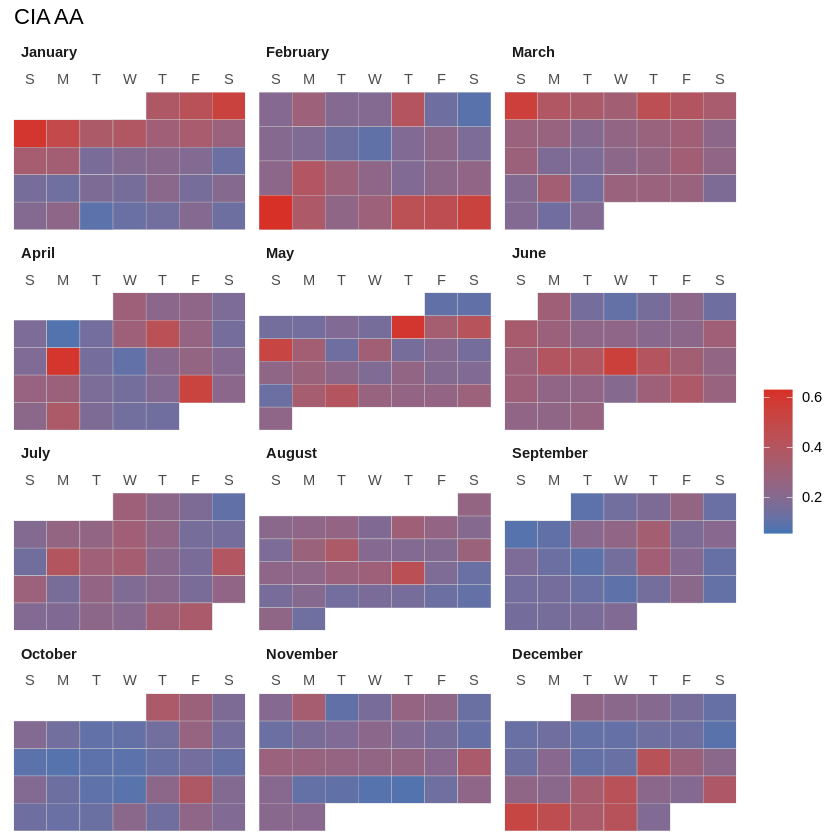

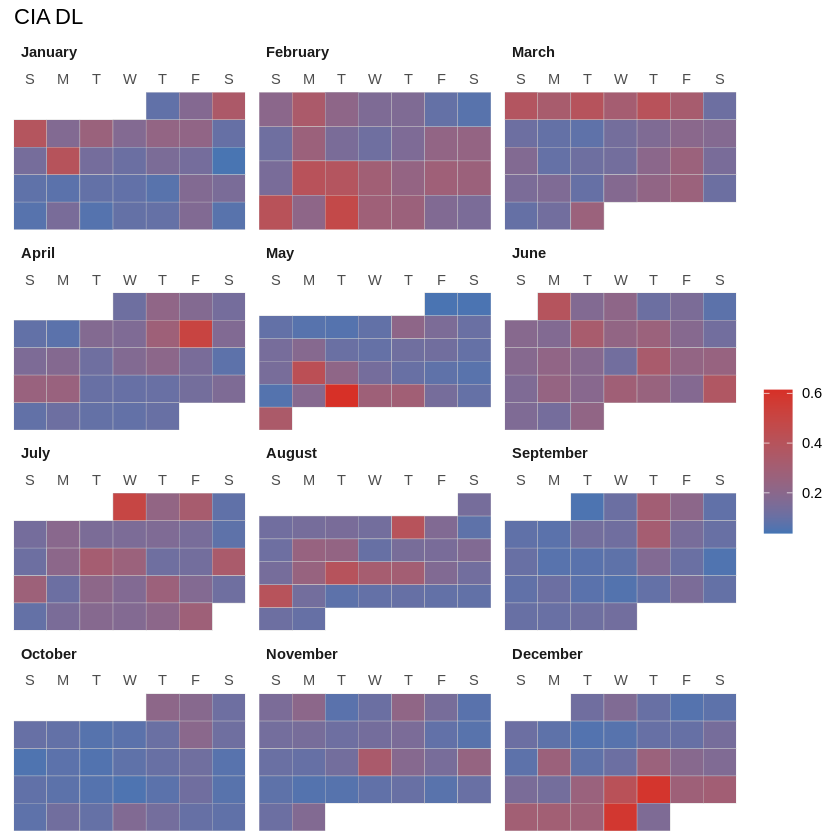

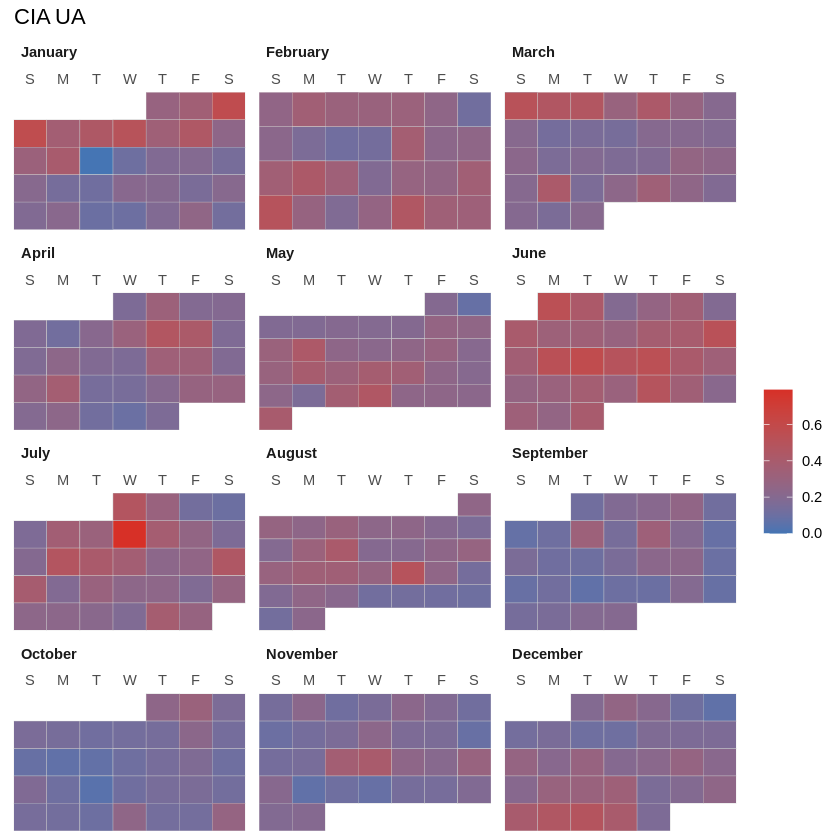

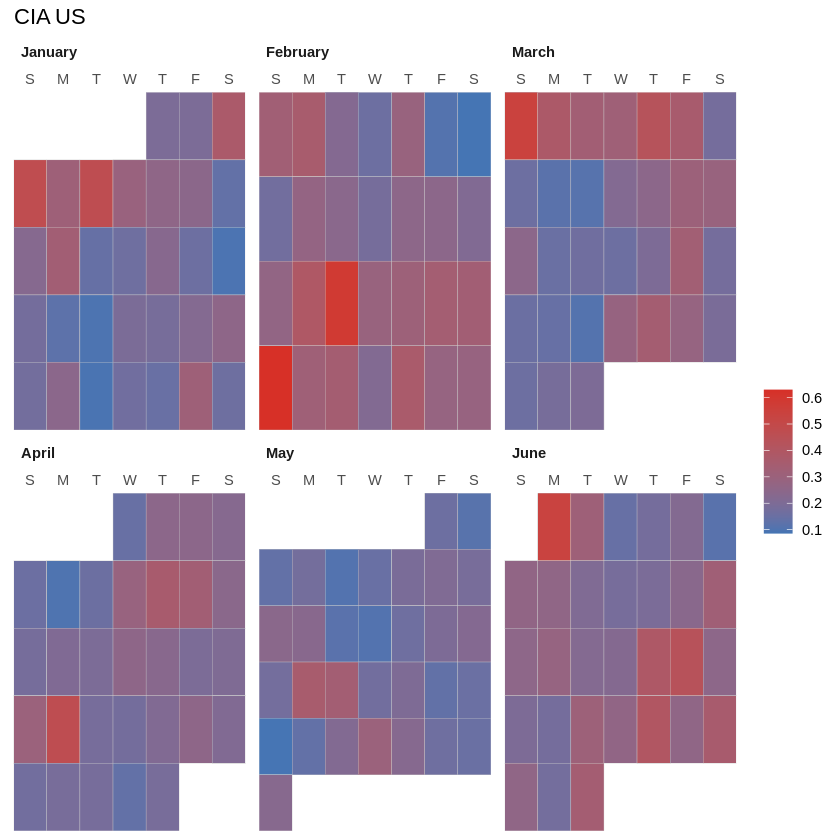

In [ ]:
paleta <- scale_fill_gradient(low = "#4575b4", high = "#d73027")

baseCalendario <- function(stats, cia){stats %>% filter(AIRLINE == cia) -> stats
  ggcal(stats$DATA, stats$p)}

baseCalendario(calendar, "AA") -> cAA
baseCalendario(calendar, "DL") -> cDL
baseCalendario(calendar, "UA") -> cUA
baseCalendario(calendar, "US") -> cUS

cAA + paleta +ggtitle("CIA AA")
cDL  + paleta + ggtitle("CIA DL")
cUA  + paleta + ggtitle("CIA UA")
cUS + paleta + ggtitle("CIA US")